<a href="https://colab.research.google.com/github/kavyachennampalli-glitch/Netflix-Data-Cleaning-Preprocessing/blob/main/netfilx_datacleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/netflix_titles.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 8807
Number of columns: 12


In [7]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [9]:
# Basic statistical summary
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [10]:
# Check the number of missing values in each column

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [11]:
# Calculate the percentage of missing values

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_table

,Missing Values,Percentage
show_id,0,0.000000
type,0,0.000000
title,0,0.000000
director,2634,29.908028
cast,825,9.367549
country,831,9.435676
date_added,10,0.113546
release_year,0,0.000000
rating,4,0.045418
duration,3,0.034064


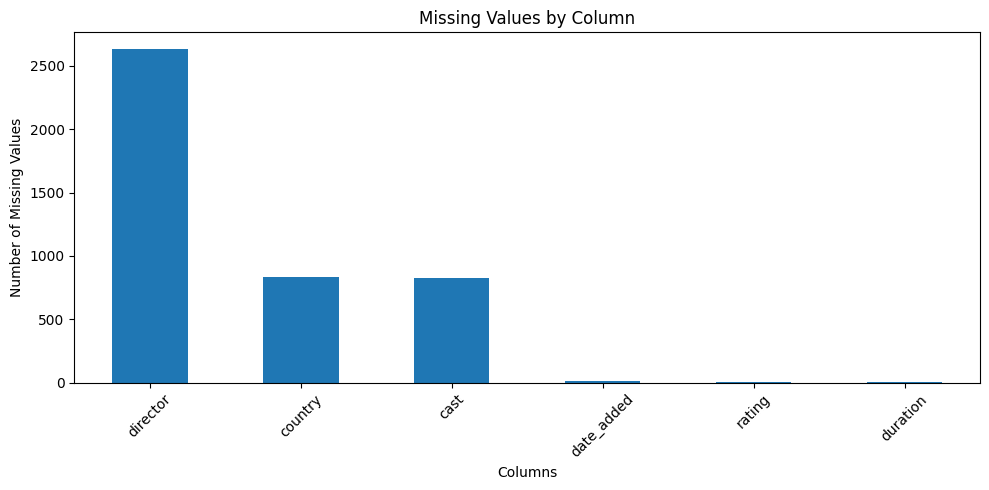

In [12]:
import matplotlib.pyplot as plt

# Select only columns that contain missing values
missing = df.isnull().sum()
missing = missing[missing > 0]

# Create a bar chart
plt.figure(figsize=(10, 5))
missing.sort_values(ascending=False).plot(kind='bar')

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Create a copy of the original dataset before cleaning
df_clean = df.copy()

print("Backup copy created successfully.")

Backup copy created successfully.


In [14]:
# Handle missing values in categorical columns

columns_to_fill = ['director', 'cast', 'country', 'rating', 'duration']

for column in columns_to_fill:
    df_clean[column] = df_clean[column].fillna('Unknown')

print("Missing categorical values handled successfully.")

Missing categorical values handled successfully.


In [15]:
# Convert date_added to datetime format

df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added'],
    errors='coerce'
)

print("date_added converted to datetime format.")

date_added converted to datetime format.


In [16]:
print("Missing date_added values:", df_clean['date_added'].isnull().sum())

Missing date_added values: 98


In [17]:
df_clean.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,98
release_year,0
rating,0
duration,0


In [18]:
# Check values that became missing after date conversion

invalid_dates = df[
    df['date_added'].notna() &
    df_clean['date_added'].isna()
]

print("Number of values that became invalid:", len(invalid_dates))

invalid_dates[['show_id', 'title', 'date_added']].head(20)

Number of values that became invalid: 88


,show_id,title,date_added
6079,s6080,Abnormal Summit,"August 4, 2017"
6177,s6178,忍者ハットリくん,"December 23, 2018"
6213,s6214,Bad Education,"December 15, 2018"
6279,s6280,Being Mary Jane: The Series,"July 1, 2017"
6304,s6305,"Big Dreams, Small Spaces","July 26, 2019"
6318,s6319,Bitten,"May 26, 2016"
6357,s6358,Bondi Rescue,"November 1, 2019"
6361,s6362,Borderline,"December 2, 2017"
6368,s6369,Brain Games,"March 15, 2019"
6393,s6394,Burnistoun,"October 1, 2019"


In [19]:
# Re-convert date_added using mixed date formats

df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added'],
    format='mixed',
    errors='coerce'
)

print("Missing date_added values after correction:",
      df_clean['date_added'].isna().sum())

Missing date_added values after correction: 98


In [20]:
# Final missing-value check after correction

df_clean.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,98
release_year,0
rating,0
duration,0


In [21]:
print(df['date_added'].dtype)
print(df['date_added'].head(20))
print(df['date_added'].tail(20))

object
0     September 25, 2021
1     September 24, 2021
2     September 24, 2021
3     September 24, 2021
4     September 24, 2021
5     September 24, 2021
6     September 24, 2021
7     September 24, 2021
8     September 24, 2021
9     September 24, 2021
10    September 24, 2021
11    September 23, 2021
12    September 23, 2021
13    September 22, 2021
14    September 22, 2021
15    September 22, 2021
16    September 22, 2021
17    September 22, 2021
18    September 22, 2021
19    September 22, 2021
Name: date_added, dtype: object
8787     December 19, 2017
8788          July 1, 2016
8789     February 27, 2019
8790     September 1, 2019
8791     November 20, 2019
8792      November 1, 2016
8793     November 20, 2019
8794      October 11, 2018
8795           May 1, 2018
8796      January 17, 2017
8797    September 13, 2018
8798     December 31, 2019
8799     February 15, 2018
8800     December 15, 2016
8801         March 9, 2016
8802     November 20, 2019
8803          July 1, 2019
88

In [22]:
# Start again from the original dataset
df_clean = df.copy()

In [23]:
# Convert date_added to datetime
df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added'],
    errors='coerce'
)

In [24]:
print("Missing dates:", df_clean['date_added'].isna().sum())

Missing dates: 98


In [25]:
df_clean = df.copy()

In [26]:
# Convert date_added using an explicit date format
df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added'],
    format='%B %d, %Y',
    errors='coerce'
)

print("Missing dates:", df_clean['date_added'].isna().sum())

Missing dates: 98


In [27]:
# Reset the cleaned dataset from the original dataset
df_clean = df.copy()

# Convert date_added correctly
df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added'].astype('string'),
    format='%B %d, %Y',
    errors='coerce'
)

print("Original missing dates:", df['date_added'].isna().sum())
print("Missing dates after cleaning:", df_clean['date_added'].isna().sum())

Original missing dates: 10
Missing dates after cleaning: 98


In [28]:
# Start again from the original dataset
df_clean = df.copy()

# Remove extra spaces from date_added
df_clean['date_added'] = df_clean['date_added'].str.strip()

# Convert to proper datetime format
df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added'],
    format='%B %d, %Y',
    errors='coerce'
)

print("Original missing dates:", df['date_added'].isna().sum())
print("Missing dates after cleaning:", df_clean['date_added'].isna().sum())

Original missing dates: 10
Missing dates after cleaning: 10


In [29]:
# Check for duplicate rows

duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)# Check for duplicate rows

duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0
Number of duplicate rows: 0


In [30]:
# Display duplicate rows if any exist

df_clean[df_clean.duplicated()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [31]:
#  Clean text spacing
text_columns = [
    "type", "title", "director", "cast",
    "country", "rating", "listed_in"
]

In [32]:
for col in text_columns:
    df[col] = df[col].astype("string").str.strip()


In [33]:
# 8. Split mixed duration into value and unit
df["duration_value"] = pd.to_numeric(
    df["duration"].astype("string").str.extract(r"(\d+)")[0],
    errors="coerce"
)

df["duration_unit"] = np.where(
    df["duration"].astype("string").str.contains(
        "Season", case=False, na=False
    ),
    "seasons",
    np.where(
        df["duration"].astype("string").str.contains(
            "min", case=False, na=False
        ),
        "minutes",
        "unknown"
    )
)


In [35]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
# 9. Create date features
df["added_year"] = df["date_added"].dt.year
df["added_month"] = df["date_added"].dt.month

In [36]:
# 10. Final checks
print(df.info())
print("Duplicates:", df.duplicated().sum())
print("Missing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   show_id         8807 non-null   object        
 1   type            8807 non-null   string        
 2   title           8807 non-null   string        
 3   director        6173 non-null   string        
 4   cast            7982 non-null   string        
 5   country         7976 non-null   string        
 6   date_added      8709 non-null   datetime64[ns]
 7   release_year    8807 non-null   int64         
 8   rating          8803 non-null   string        
 9   duration        8804 non-null   object        
 10  listed_in       8807 non-null   string        
 11  description     8807 non-null   object        
 12  duration_value  8804 non-null   Int64         
 13  duration_unit   8807 non-null   object        
 14  added_year      8709 non-null   float64       
 15  adde

In [37]:
# 11. Save cleaned data
df.to_csv("netflix_titles_cleaned.csv", index=False)